In [1]:
import numpy as np

class Ray:
    def __init__(self, o, d):
        self.o = np.array(o, float)
        self.d = np.array(d, float)
        self.d /= (np.linalg.norm(self.d) + 1e-12)

class Material:
    def __init__(self, color=(1,1,1), ka=0.1, kd=0.8, ks=0.5, shininess=64,
                 reflective=0.0, transparent=0.0, ior=1.5):
        self.color = np.array(color, float)
        self.ka = float(ka)
        self.kd = float(kd)
        self.ks = float(ks)
        self.shininess = float(shininess)
        self.reflective = float(reflective)      # for opaque mirror-ish
        self.transparent = float(transparent)    # for glass
        self.ior = float(ior)                    # index of refraction

class Sphere:
    def __init__(self, center, radius, material):
        self.c = np.array(center, float)
        self.r = float(radius)
        self.mat = material

In [2]:
def intersect_sphere(ray: Ray, sph: Sphere):
    # Solve ||o + t d - c||^2 = r^2
    oc = ray.o - sph.c
    a = np.dot(ray.d, ray.d)
    b = 2.0 * np.dot(oc, ray.d)
    c = np.dot(oc, oc) - sph.r*sph.r
    disc = b*b - 4*a*c
    if disc < 0:
        return None
    s = np.sqrt(disc)
    t0 = (-b - s) / (2*a)
    t1 = (-b + s) / (2*a)
    t = None
    if t0 > 1e-4:
        t = t0
    elif t1 > 1e-4:
        t = t1
    if t is None:
        return None
    p = ray.o + t * ray.d
    n = (p - sph.c) / (sph.r + 1e-12)
    return t, p, n

def reflect(v, n):
    return v - 2.0 * np.dot(v, n) * n

def refract(v, n, eta_i, eta_t):
    """
    v: incident direction (pointing *into* surface)
    n: normal (pointing outward)
    returns (did_refract, refr_dir)
    """
    cosi = np.clip(-np.dot(v, n), -1.0, 1.0)
    eta = eta_i / eta_t
    k = 1.0 - eta*eta * (1.0 - cosi*cosi)
    if k < 0.0:
        return False, None  # total internal reflection
    tdir = eta * v + (eta*cosi - np.sqrt(k)) * n
    tdir /= (np.linalg.norm(tdir) + 1e-12)
    return True, tdir

def fresnel_schlick(cos_theta, F0):
    # Schlick approximation
    return F0 + (1 - F0) * (1 - cos_theta)**5

def find_nearest(ray, objects):
    best = None
    for obj in objects:
        hit = intersect_sphere(ray, obj)
        if hit is None:
            continue
        t, p, n = hit
        if best is None or t < best[0]:
            best = (t, p, n, obj)
    return best

In [3]:
def phong_lighting(p, n, vdir, obj, light_pos, light_intensity, ambient_intensity, objects):
    mat = obj.mat
    color = mat.color

    # Ambient
    amb = ambient_intensity * mat.ka * color

    # Shadow check
    toL = light_pos - p
    distL = np.linalg.norm(toL)
    ldir = toL / (distL + 1e-12)
    shadow_ray = Ray(p + n*1e-4, ldir)
    block = find_nearest(shadow_ray, objects)
    in_shadow = False
    if block is not None and block[0] < distL:
        in_shadow = True

    if in_shadow:
        return amb

    # Diffuse
    ndotl = max(np.dot(n, ldir), 0.0)
    diff = light_intensity * mat.kd * ndotl * color

    # Specular (Blinn-Phong)
    h = (ldir + vdir)
    h /= (np.linalg.norm(h) + 1e-12)
    ndoth = max(np.dot(n, h), 0.0)
    spec = light_intensity * mat.ks * (ndoth ** mat.shininess) * np.ones(3)

    return amb + diff + spec

In [ ]:
def background_color(ray):
    # high-contrast sky gradient to make reflections visible
    t = 0.5 * (ray.d[1] + 1.0)  # [-1,1] -> [0,1]
    return (1-t)*np.array([0.02, 0.02, 0.05]) + t*np.array([0.75, 0.85, 1.0])
    
def trace_ray(ray, objects, light_pos,
              light_intensity=1.0, ambient_intensity=0.2,
              depth=0, max_depth=5):
    if depth >= max_depth:
        return background_color(ray)

    hit = find_nearest(ray, objects)
    if hit is None:
        return background_color(ray)

    t, p, n_out, obj = hit
    mat = obj.mat

    # view dir (point -> camera)
    vdir = -ray.d
    vdir /= (np.linalg.norm(vdir) + 1e-12)

    # normal for shading only (face viewer)
    n_shade = n_out if np.dot(ray.d, n_out) < 0 else -n_out

    # local lighting (Phong). For glass we keep only a small contribution later.
    direct = phong_lighting(p, n_shade, vdir, obj, light_pos,
                            light_intensity, ambient_intensity, objects)

    # ---------- OPAQUE ----------
    if mat.transparent <= 0.0:
        if mat.reflective > 0.0:
            rdir = reflect(ray.d, n_shade)
            refl = trace_ray(Ray(p + n_shade*1e-4, rdir),
                             objects, light_pos,
                             light_intensity, ambient_intensity,
                             depth+1, max_depth)
            return np.clip((1.0-mat.reflective)*direct + mat.reflective*refl, 0, 1)

        return np.clip(direct, 0, 1)

    # ---------- GLASS ----------
    # entering/exiting decision uses outward normal (unforced)
    entering = (np.dot(ray.d, n_out) < 0)

    if entering:
        eta_i, eta_t = 1.0, mat.ior   # air -> glass
        n_use = n_out
        refl_origin = p + n_use*1e-4
        refr_origin = p - n_use*1e-4
    else:
        eta_i, eta_t = mat.ior, 1.0   # glass -> air
        n_use = -n_out                # flip to oppose incident direction
        refl_origin = p + n_use*1e-4
        refr_origin = p - n_use*1e-4

    # Fresnel (Schlick)
    cos_theta = np.clip(-np.dot(ray.d, n_use), 0.0, 1.0)
    F0 = ((eta_t - eta_i) / (eta_t + eta_i))**2
    Fr = fresnel_schlick(cos_theta, F0)

    # Reflection ray
    rdir = reflect(ray.d, n_use)
    refl = trace_ray(Ray(refl_origin, rdir),
                     objects, light_pos,
                     light_intensity, ambient_intensity,
                     depth+1, max_depth)

    # Refraction ray
    did_refract, tdir = refract(ray.d, n_use, eta_i, eta_t)
    if did_refract:
        refr = trace_ray(Ray(refr_origin, tdir),
                         objects, light_pos,
                         light_intensity, ambient_intensity,
                         depth+1, max_depth)
    else:
        # total internal reflection
        refr = np.zeros(3, dtype=float)
        Fr = 1.0

    # Small direct term to show a light highlight on glass
    direct_weight = 0.12  # 0.05–0.15 reasonable
    color = direct_weight*direct + Fr*refl + (1.0-Fr)*refr
    return np.clip(color, 0, 1)

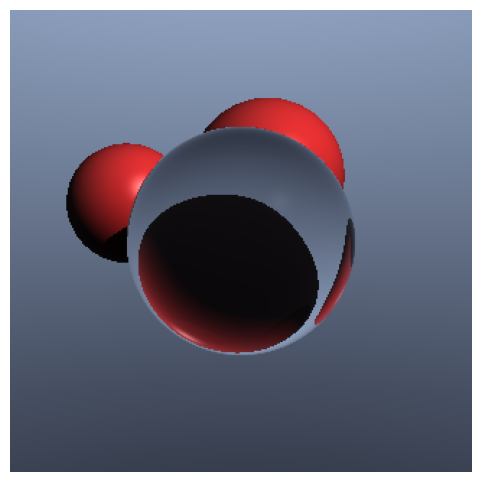

In [6]:
import matplotlib.pyplot as plt

def render(camera_origin, camera_lookat, width=400, height=400, fov_deg=60,
           objects=None, light_pos=(5,5,2)):
    if objects is None:
        objects = []

    o = np.array(camera_origin, float)
    look = np.array(camera_lookat, float)
    up = np.array([0,1,0], float)

    forward = (look - o); forward /= np.linalg.norm(forward)
    right = np.cross(forward, up); right /= np.linalg.norm(right)
    true_up = np.cross(right, forward); true_up /= np.linalg.norm(true_up)

    aspect = width / height
    scale = np.tan(np.deg2rad(fov_deg)*0.5)

    img = np.zeros((height, width, 3), float)

    for y in range(height):
        for x in range(width):
            px = (2*(x+0.5)/width - 1) * aspect * scale
            py = (1 - 2*(y+0.5)/height) * scale
            d = forward + px*right + py*true_up
            ray = Ray(o, d)
            img[y,x] = trace_ray(ray, objects, np.array(light_pos,float),
                     light_intensity=1.2, ambient_intensity=0.2,
                     depth=0, max_depth=6)
    return np.clip(img, 0, 1)

# Scene: glass ball + opaque ball behind
glass = Material(
    color=(1,1,1),
    ka=0.0, kd=0.0,
    ks=0.25, shininess=256,
    reflective=0.0,
    transparent=1.0,
    ior=1.5
)
opaque = Material(color=(0.85, 0.15, 0.15), ka=0.1, kd=0.9, ks=0.4, shininess=64,
                  reflective=0.05, transparent=0.0)

objs = [
    Sphere(center=(0.0, 0.0, -4.0), radius=1.0, material=glass),
    Sphere(center=(0.4,1, -7.0), radius=1.2, material=opaque),
    Sphere(center=(-1.5,0.5, -6.0), radius=0.8, material=opaque)
]

img = render(camera_origin=(0,0,0), camera_lookat=(0,0,-1),
             width=320, height=320, fov_deg=55, objects=objs, light_pos=(5,5,2))

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.show()

How to vectorise the recursive Ray tracer:
I honestly don't know how I would go about this given that vectorisation depends on performing the same operation accross the whole array, but depending on what the rays hit, say one ray hits glass and another an opaque ball, we're dealing with very different situations regarding the child-rays.
I can see how you could vectorise the first ray, so you have all the rayhits, calculate their shading and colour, then do the same again over and over for the situation without glass and you just use a mask to determine which ones have hit the light source or not.
As for the case of reflection and refraction, there is the heuristic way of just picking one of the rays, either reflection or refraction, after all Fresnell gives us a way to put reflection and refraction as related to each other so we can use that as a probability and then use stochastics to only propagate one route.
alternatively you could generate a separate array for each newly generated ray divergence and then vectorise those, multiple arrays would also paralelize well on the GPU.


For time reasons I couldn't attempt to implement the vectorized recursive raytracer as I was sick this week.